In [2]:
#importing libraries

import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to C:\Users\gauri bharat
[nltk_data]     thakare\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\gauri bharat
[nltk_data]     thakare\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
#loading Dataset

df = pd.read_csv('IMDB Dataset.csv')
print(df.shape)
print(df['sentiment'].value_counts())

(50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [ ]:
#Text Preprocessing
#Lemmatization means the words with the similar meaning could easily get recognized and can be treat similarly.

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = re.sub(r'<.*?', ' ',text)
    text = re.sub(r'[^a-zA-Z\s]', ' ',text)
    text = text.lower()
    text = text.replace(' br ', ' ')
    words = text.split()
    words = [lemmatizer.lemmatize(word)for word in words if word not in stop_words]
    return' '.join(words)

In [ ]:
#Sample/Example for how text processing is actually done.

sample = df['review'][0]
print("ORIGINAL:\n",sample[:200])
print("\nCLEANED:\n",clean_text(sample)[:200])

ORIGINAL:
 One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

CLEANED:
 one reviewer mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch reg


In [6]:
df['cleaned_review'] = df['review'].apply(clean_text)
print(df[['review','cleaned_review']].head())

                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                      cleaned_review  
0  one reviewer mentioned watching oz episode hoo...  
1  wonderful little production filming technique ...  
2  thought wonderful way spend time hot summer we...  
3  basically family little boy jake think zombie ...  
4  petter mattei love time money visually stunnin...  


In [ ]:
#Sentiments Label Encoding.

df['sentiment_label'] = df['sentiment'].map({'positive': 1,'negative': 0})

print(df[['sentiment', 'sentiment_label']].head())
print(df['sentiment_label'].isnull())

  sentiment  sentiment_label
0  positive                1
1  positive                1
2  positive                1
3  negative                0
4  positive                1
0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Name: sentiment_label, Length: 50000, dtype: bool


In [ ]:
#Training-Testing-splitting Data.
#Train data was 80%, Test was done with 20% data.

x = df['cleaned_review']
y = df['sentiment_label']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", x_train.shape)
print("Test size:", x_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())


Train size: (40000,)
Test size: (10000,)
sentiment_label
1    20000
0    20000
Name: count, dtype: int64
sentiment_label
0    5000
1    5000
Name: count, dtype: int64


In [ ]:
#TF-IDF(Term Frequency-Inverse Document Frequency).

tfidf = TfidfVectorizer(max_features=5000)

x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

print("Train TF-IDF shape:", x_train_tfidf.shape)
print("Test TF-IDF shape:", x_test_tfidf.shape)


Train TF-IDF shape: (40000, 5000)
Test TF-IDF shape: (10000, 5000)


In [ ]:
#Model Training -Logistic Regression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(x_train_tfidf, y_train)

y_pred_lr = lr_model.predict(x_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(np.unique(y_pred_lr, return_counts=True))

Logistic Regression Accuracy: 0.8913
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      5000
           1       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

(array([0, 1]), array([4893, 5107]))


In [ ]:
#Model Training - Navie Bayes

nb_model = MultinomialNB()
nb_model.fit(x_train_tfidf, y_train)

y_pred_nb = nb_model.predict(x_test_tfidf)

print("Navie Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Navie Bayes Accuracy: 0.8548
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      5000
           1       0.85      0.86      0.86      5000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



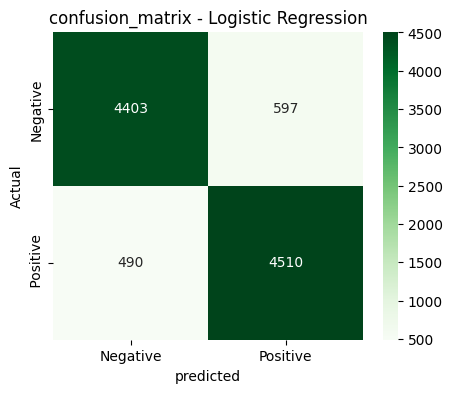

In [ ]:
#Derived the Confusion Matrix to locate the difference between both the models.

import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot= True, fmt='d', cmap='Greens', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', ' Positive'])
plt.xlabel('predicted')
plt.ylabel('Actual')

plt.title('confusion_matrix - Logistic Regression')
plt.show()


In [13]:
x_test_reset = x_test.reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

wrong_preds = x_test_reset[y_test_reset != y_pred_lr]
print("Total Wrong Predictions:", len(wrong_preds))
print(wrong_preds.head(5))


Total Wrong Predictions: 1087
14    little quentin seems mastered art cake eating ...
26    farrah fawcett give award nominated performanc...
35    known brad linaweaver florida state u early in...
42    order enjoy fur imaginary portrait diane arbus...
45    quite fan novelist screenwriter michael chabon...
Name: cleaned_review, dtype: object


In [ ]:
#Custom Prediction(Demo).

def predict_sentiment(text):
    cleaned = clean_text(text)
    vec = tfidf.transform([cleaned])
    pred = lr_model.predict(vec)[0]
    return "Positive" if pred == 1 else "Negative"

print(predict_sentiment("This movie was absolutely Wonderful, I loved every minute!"))
print(predict_sentiment("Wate of time, boring and poorly acted."))    

Positive
Negative


In [16]:
import pickle

with open('sentiment_model.pkl','wb') as f: pickle.dump(lr_model,f)
with open('tfidf_vectorizer.pkl','wb') as f: pickle.dump(tfidf,f)
print("Model and vectorizer saved!")

Model and vectorizer saved!
